In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

### Functions 

In [2]:
def get_x_prime(x, c, d, s, m):
    """
    Eq. 3 in the paper
    """
    x1, x2, x3, x4 = x
    c0, c1, c2, c3 = c
    d0, d1, d2, d3 = d

    α = d3*x1 + d1*x3
    β = c3*x1 + c2*x2
    γ = d2*x2 + d0*x4
    δ = c1*x3 + c0*x4
    η = d3*x2 + d1*x4
    ϕ = c1*x1 + c0*x2
    µ = d2*x1 + d0*x3
    ν = c3*x3 + c2*x4

    p = x1 + x2
    q = x1 + x3

    Z = α*β + γ*δ + η*ϕ + µ*ν

    first_line = 1 + (s**2)*Z + s*(d3*p**2 + (d1+d2)*p*(1-p) + d0*(1-p)**2 +
                                   c3*q**2 + (c1+c2)*q*(1-q) + c0*(1-q)**2)
    second_line = m*s*((1 + s*c3)*(α*x1 + µ*x3) + (1 + s*d3)*(β*x1 + ϕ*x2))
    third_line = m*(p**2*(1 + s*d3) + q**2*(1 + s*c3)) + (m**2)*(x1**2)*(1 + s*d3)*(1 + s*c3)
    M = first_line + second_line + third_line

    M_x1_prime = (Z + m**2*d3*c3*x1**2 + m*(d3*(β*x1 + ϕ*x2) + c3*(α*x1 + µ*x3)))*(1+s)**2 
    M_x2_prime = (-Z + m**2*d3*(1-c3)*x1**2 + m*(-d3*(β*x1 + ϕ*x2) +(1-c3)*(α*x1 + µ*x3)) 
                  + p*(α+η) + (1-p)*(γ+µ) + m*d3*p**2)*(1+s) 
    M_x3_prime = (-Z + m**2*(1-d3)*c3*x1**2 + m*((1-d3)*(β*x1 + ϕ*x2) - c3*(α*x1+µ*x3))
                  + q*(β+ν) + (1-q)*(δ+ϕ) + m*c3*q**2)*(1+s)
    M_x4_prime = (Z + m**2*(1-d3)*(1-c3)*x1**2+ m*(-(1-d3)*(β*x1+ϕ*x2) -(1-c3)*(α*x1 +µ*x3))
                  + 1-p*(α + η)-(1-p)*(γ + µ) -q*(β + ν) -(1-q)*(δ + ϕ)
                  + m*((1-d3)*p**2 +(1-c3)*q**2))

    return [M_x1_prime/M, M_x2_prime/M, M_x3_prime/M, M_x4_prime/M]

In [3]:
def get_final_h(x, c, d, s, m):
    for i in range(1000): 
        x_prime = get_x_prime(x, c, d, s, m)
        x = x_prime
    final_h = x[2] + x[3]
    return final_h

### Figure 2

In [4]:
d1_values = np.arange(0,1,0.01) 
s_values = np.arange(0,1,0.01) 

In [5]:
small_freq = 1e-7
x = [0.5 - 0.6*small_freq, 0.5 - 0.4*small_freq, 0.45*small_freq, 0.55*small_freq]
c = [0, 0.6, 0.6, 0.5]
m = 0    
results = np.empty((len(s_values), len(d1_values)))

start = time.time()
for i, s in enumerate(s_values):
    for j, d1 in enumerate(d1_values):
        d = [0, d1, d1, 1]
        results[i, j] = get_final_h(x, c, d, s, m)

end = time.time()
print(f"Time: {(end - start)/60} minutes")

Time: 1.2935985008875528 minutes


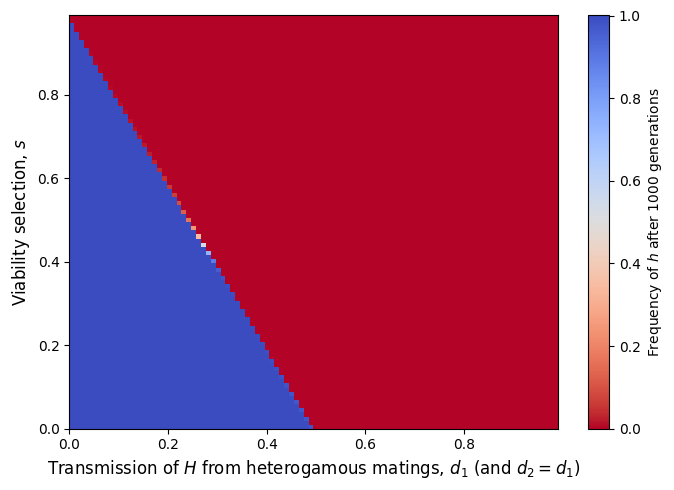

In [6]:
plt.figure(figsize=(7, 5))
im = plt.imshow(results, origin="lower", aspect="auto", interpolation="nearest",
                extent=[min(d1_values), max(d1_values), min(s_values), max(s_values)],
                cmap = "coolwarm_r")
plt.colorbar(im, label=r"Frequency of $h$ after 1000 generations")
plt.xlabel(r"Transmission of $H$ from heterogamous matings, $d_1$ (and $d_2 = d_1$)", fontsize=12)
plt.ylabel(r"Viability selection, $s$", fontsize = 12)
plt.tight_layout()
plt.savefig('figure2.pdf', bbox_inches = 'tight')
plt.show()